# Create mdreg data

In [1]:
import os
import time
import numpy as np
import mdreg
import time
import numpy as np
from tqdm import tqdm
import dask.array as da
import zarr
from mdreg import fit_models, elastix, skimage, ants, io
import pydicom


import dicom_to_zarr
import helpers

Convertion of dicom data.

In [2]:
# Define paths (please adjust if needed)
dicom_folder = 'MRI-Datasets/159277_B1/15/DICOM' 
zarr_file = 'MRI-Datasets/Converted_to_zarr/159277_B1.zarr'

# Make sure the folder exists before calling the function
if not os.path.exists(dicom_folder):
    os.makedirs(dicom_folder)
    print(f"Folder '{dicom_folder}' was created. Please fill it with your DICOM files.")
elif not os.listdir(dicom_folder):
    print(f"The folder '{dicom_folder}' is empty. Please add DICOM files to run the script.")
else:
    # Call the conversion function
    dicom_to_zarr.convert_dicom_to_zarr(dicom_folder, zarr_file)

Lese DICOM-Dateien aus: MRI-Datasets/159277_B1/15/DICOM
Stapele DICOM-Schichten zu einem 3D-Raum...
Extrahierte Metadaten: {'PixelSpacing': [1.9531, 1.9531], 'SliceThickness': 5.0, 'Rows': 256, 'Columns': 256, 'PatientID': 'MEDCIC_07_B1'}
Speichere Array der Größe (12500, 256, 256) in MRI-Datasets/Converted_to_zarr/159277_B1.zarr...
Konvertierung abgeschlossen!


## Exploratory Data Analysis (EDA) of the Zarr File

In [3]:
dicom = pydicom.dcmread('MRI-Datasets/159277_B1/15/DICOM/MR012195.dcm')

In [4]:
dicom.ang

AttributeError: 'FileDataset' object has no attribute 'ang'

In [4]:
try:
    z_array = zarr.open(zarr_file, mode='r')

    # Print metadata and array properties
    metadata = z_array.attrs['metadata']
    print(f"Zarr array successfully loaded.")
    print(f"Shape: {z_array.shape}")
    print(f"Dtype: {z_array.dtype}")
    print(f"Stored Metadata: {metadata}")
    
    DATA_LOADED = True
except FileNotFoundError:
    print(f"Error: '{zarr_file}' not found. Please ensure Part 1 ran successfully.")
    DATA_LOADED = False

Zarr array successfully loaded.
Shape: (12500, 256, 256)
Dtype: int16
Stored Metadata: {'PixelSpacing': [1.9531, 1.9531], 'SliceThickness': 5.0, 'Rows': 256, 'Columns': 256, 'PatientID': 'MEDCIC_07_B1'}


In [5]:
dask_array = da.from_array(z_array)

In [6]:
dask_array = np.transpose(dask_array, [0,1,2])
dask_array = dask_array.reshape([250,50,256,256])
dask_array = np.transpose(dask_array, [3,2,1,0])

In [7]:
dask_array.to_zarr('MRI-Datasets/input_zarr_for_mdreg.zarr')

ContainsArrayError: An array exists in store LocalStore('file://MRI-Datasets/input_zarr_for_mdreg.zarr') at path ''.

In [12]:
input_array = zarr.load('MRI-Datasets/input_zarr_for_mdreg.zarr')

In [13]:
tacq = dicom.AcquisitionTime
aif = dicom.waveform_array
spacing = dicom.SpacingBetweenSlices
t0, t1 = 10, 15

In [14]:
dicom.waveform_array

<bound method Dataset.waveform_array of Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 200
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.113619.2.453.1599194.968011.28192.1733125187.482
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.8
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_368'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'OTHER']
(0008,0016) SOP Class UID                       UI: MR Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.840.113619.2.453.1599194.968011.28192.1733125187.482
(0008,

In [15]:
def fit_parallel(moving,
        fit_pixels = None,
        fit_coreg = None,
        fit_image = None,
        tol = 1e-6,    
        maxit = 5,
        verbose = 0,
        force_2d = False,
        path = None, 
    ):
    """
    Remove motion from a series of 2D- or 3D images.

    Parameters
    ----------
    moving : numpy.ndarray | zarr.Array
        The series of images to be corrected, with dimensions (x,y,t) or (x,y,z,t). 
    fit_pixels : dict, optional
        A dictionary defining a single-pixel signal model. The possible items 
        in the dictionary are the keywords of the function `mdreg.fit_pixels`. 
        For a slice-by-slice computation (4D array with force_2d=True), 
        *fit_pixels* can be a list of dictionaries, one for each slice. 
        The default is None.
    fit_coreg : dict, optional
        The parameters for coregistering the images. *fit_coreg* has one 
        required item 'package' with possible values 'skimage' (default), 
        'elastix' and 'ants'. The other parameters are the possible keywords 
        of the *coreg_series* function of the package specified. 
    fit_image : dict or list, optional
        A dictionary defining the function to fit the signal data, and its 
        parameter values. This argument is ignored if *fit_pixels* is already 
        provided. *fit_image* has one required key 'func' that specifies the 
        fit function to use. The other entries are the keyword arguments of 
        this fit function. 
        The fit function can be one of the functions built in to mdreg, or a 
        custom made function. A valid fit function *must* take a signal array 
        as argument, and return two variables: an array with the same shape 
        containing the fit to the model, and a second variable that contains 
        the fitted parameters. 
        For a slice-by-slice computation (4D array with force_2d=True), 
        *fit_image* can be a list of dictionaries, one for each slice. 
        If *fit_image* is not provided, a constant model is used. 
    tol : float, optional
        Stopping criterion for the iteration. The iteration stops if the 
        largest difference between new and old coregistered series in any 
        pixel at any time point is less than *tol* of the largest value. 
        The default is 1e-6.
    maxit : int, optional
        The maximum number of iterations. The default is 0.
    verbose : int, optional
        The level of feedback to provide to the user. 0: no feedback; 1: text 
        output only; 2: text output and progress bars. The default is 2.
    force_2d : bool, optional
        By default, a 3-dimensional moving array will be coregistered with a 
        3-dimensional deformation field. To perform slice-by-slice 
        2-dimensional registration instead, set *force_2d* to True. This 
        keyword is ignored when the arrays are 2-dimensional. The 
        default is False.
    path : str, optional
        Path on disk where to save the results. If no path is provided, the 
        results are not saved to disk. Defaults to None.

    Returns
    -------
    coreg : numpy.ndarray | zarr.Array
        The coregistered images with the same dimensions as *moving*.
    fit : numpy.ndarray | zarr.Array
        The fitted signal model with the same dimensions as *arr*.
    transfo : numpy.ndarray | zarr.Array | list
        The parameters of the transformation deforming the moving image to the 
        coregistered image. With skimage, this is the deformation field with 
        the same dimensions as *moving*, and one additional dimension for the 
        components of the vector field. With elastix this is an array of 
        parameter objects and with ants this is an array of files with 
        transform parameters. Note when force_2d = True these are 2-dimensional 
        arrays with one transform per slice and per time point.
    pars : numpy.ndarray | zarr.Array
        The parameters of the fitted signal model with dimensions (x,y,n) or 
        (x,y,z,n), where n is the number of free parameters of the signal 
        model.
 
    """

    print("Test")
    
    # Set defaults in fit_coreg
    if fit_coreg is None:
        fit_coreg = {'package': 'skimage'}
    if 'package' not in fit_coreg:
        fit_coreg['package'] = 'skimage'
    #if 'progress_bar' not in fit_coreg:
        #fit_coreg['progress_bar'] = verbose>1
    if 'name' not in fit_coreg:
        fit_coreg['name'] = 'coreg'

    # 2D slice-by-slice coregistration
    if moving.ndim==4:
        if force_2d:
            return  _fit_force_2d(
               moving, fit_image, fit_coreg, fit_pixels, tol, maxit, 
               verbose, path, 
            )
        
    # Set defaults for fit_image  
    if fit_image is None:
        fit_image = {'func': fit_models.fit_constant}

    # Check inputs
    if not isinstance(fit_image, dict):
        raise ValueError('The fit_image argument must be a dictionary.')

    # Set paths    
    _set_path(fit_coreg, path)
    _set_path(fit_image, path)
    _set_path(fit_pixels, path)

    # Compute
    converged = False
    it = 1
    start = time.time()

    if verbose > 0:
        print('Initializing..')
    coreg = io._copy(moving, path, 'coreg')

    while not converged: 

        startit = time.time()

        # Fit signal model
        if verbose > 0:
            print(f'Iteration {it}: fitting signal model')
        if fit_pixels is not None:
            fit, pars = fit_models.fit_pixels(coreg, **fit_pixels)
        else:
            kwargs = {i:fit_image[i] for i in fit_image if i!='func'}
            fit, pars = fit_image['func'](coreg, **kwargs)

        # Fit deformation
        if verbose > 0:
            print(f'Iteration {it}: fitting deformation fields')
        coreg_curr = io._copy(coreg, path, 'tmp')
        vals = _coreg_series(moving, fit, **fit_coreg)
        coreg, transfo = vals[:2]

        # Check convergence
        converged = _diff(coreg, coreg_curr) < tol
        
        if verbose > 0:
            print(f'Calculation time for iteration {it}: '
                  f'{(time.time()-startit)/60} min')  

        if it == maxit: 
            break

        it += 1 

    if verbose > 0:
        print(f'Total calculation time: {(time.time()-start)/60} min')

    io._remove(path, 'tmp')
    if len(vals) > 2: # optional return value
        defo = vals[2]
        return coreg, fit, transfo, pars, defo
    else:
        return coreg, fit, transfo, pars


def _fit_force_2d(
        moving, fit_image, fit_coreg, fit_pixels, tol, maxit, verbose, 
        path,
    ):

    # Required outputs
    coreg = io._copy(moving, path, 'coreg')
    if fit_coreg['package'] == 'skimage':
        transfo = io._defo(
            moving, 
            path, 
            force_2d=True, 
            name=fit_coreg['name']+'_defo',
        )
    else:
        transfo = np.empty(moving.shape[-2:], dtype=object)

    # Optional outputs
    defo = None
    if 'return_deformation' in fit_coreg:
        if fit_coreg['return_deformation']:
            defo = io._defo(
                moving, 
                path, 
                force_2d=True, 
                name=fit_coreg['name']+'_defo',
            )

    for k in tqdm(
            range(moving.shape[2]), 
            desc='Fitting slice', 
            disable=verbose<2,
        ):
        if verbose == 1:
            print(f'Fitting slice {k+1} / {moving.shape[2]}')

        if fit_image is None:
            fit_image_k = None
        elif isinstance(fit_image, dict):
            fit_image_k = fit_image
        else:
            fit_image_k = fit_image[k]

        if fit_pixels is None:
            fit_pixels_k = None
        elif isinstance(fit_pixels, dict):
            fit_pixels_k = fit_pixels
        else:
            fit_pixels_k = fit_pixels[k]

        vals = fit_parallel(
            moving[:,:,k,:],
            fit_pixels = fit_pixels_k,
            fit_image = fit_image_k,
            fit_coreg = fit_coreg,
            tol = tol,
            maxit = maxit,
            verbose = verbose,
        )
        coreg[:,:,k,:], fit_k, transfo_k, pars_k = vals[:4]
        if k == 0:
            fit_arr, pars = io._fit_models_init(moving, path, pars_k.shape[-1])              
        if fit_coreg['package'] == 'skimage':
            transfo[:,:,k,:,:] = transfo_k
        else:
            transfo[k,:] = transfo_k
        fit_arr[:,:,k,:] = fit_k
        pars[:,:,k,:] = pars_k
        if defo is not None:
            defo[:,:,k,:,:] = vals[4]
    if defo is None:
        return coreg, fit_arr, transfo, pars
    else:
        return coreg, fit_arr, transfo, pars, defo



def _set_path(dct, path):
    if dct is None:
        return
    if path is None:
        return
    if 'path' in dct:
        if path != dct['path']:
            raise ValueError("Two different paths are provided.")
    else:
        dct['path'] = path
        

def _diff(coreg, coreg_curr):
    if isinstance(coreg, np.ndarray):
        corr = np.max(np.abs(coreg-coreg_curr))/np.max(np.abs(coreg_curr))
    else:
        coreg = da.from_zarr(coreg) 
        coreg_curr = da.from_zarr(coreg_curr)    
        corr = da.max(da.abs(coreg-coreg_curr))/da.max(da.abs(coreg_curr))
        corr.compute()
    return corr


def _coreg_series(moving, fit, package='elastix', **fit_coreg):

    if package == 'elastix':
        print('elastix')
        fit_coreg = _set_mdreg_elastix_defaults(fit_coreg)
        return elastix.coreg_series(moving, fit, **fit_coreg)
    
    elif package == 'skimage':
        print("parallelization")
        return skimage.coreg_series(moving, fit, **fit_coreg, parallel=True, progress_bar=False)
    
    elif package == 'ants':
        print('ants')
        return ants.coreg_series(moving, fit, **fit_coreg)
    
    else:
        raise NotImplementedError(
            'This coregistration package is not implemented')
    

def _set_mdreg_elastix_defaults(params):

    if "WriteResultImage" not in params:
        params["WriteResultImage"] = "false"
    if "WriteDeformationField" not in params:
        params["WriteDeformationField"] = "false"
    if "ResultImagePixelType" not in params:
        params["ResultImagePixelType"] = "float"

    # # Removing this for v0.4.2 as results appear to be worse
    # if 'Metric' not in params:
    #     params["Metric"] = "AdvancedMeanSquares"

    # # Settings pre v0.4.0 - unclear why - removed for now
    # if "FinalGridSpacingInPhysicalUnits" not in params:
    #     params["FinalGridSpacingInPhysicalUnits"] = "50.0"
    # if "AutomaticParameterEstimation" not in params:
    #     params["AutomaticParameterEstimation"] = "true"
    # if "ASGDParameterEstimationMethod" not in params:
    #     params["ASGDParameterEstimationMethod"] = "Original"
    # if "MaximumStepLength" not in params:
    #     params["MaximumStepLength"] = "1.0"
    # if "CheckNumberOfSamples" not in params:
    #     params["CheckNumberOfSamples"] = "true"
    # if "RandomCoordinate" not in params:
    #     params["ImageSampler"] = "RandomCoordinate"

    return params

In [16]:
tacq = dicom.AcquisitionTime
aif = dicom
spacing = dicom.SpacingBetweenSlices
t0, t1 = 10, 15

In [17]:
dicom[0x0018, 0x0013]

KeyError: (0018,0013)

In [18]:
def my_molli(TI, S0, T1):
    return np.abs(S0 * (1 - 2 * np.exp(-TI/T1)))

In [19]:
def fit_my_molli(array, TI=None):

    # Reshape the image array for convenience
    shape = array.shape
    array = array.reshape((-1,shape[-1]))

    # Define output arrays in the new shape
    nx, nt = array.shape
    par = np.zeros((nx, 2))
    fit = np.zeros((nx, nt))

    # Fit the model for each pixel
    for x in range(nx):
        try:
            par[x,:], _ = curve_fit(
                my_molli, TI, array[x,:],
                p0 = [np.amax(np.abs(array[x,:])), 1.3],
                bounds = (0, np.inf),
            )
            fit[x,:] = my_molli(TI, par[x,0], par[x,1])
        except:
            fit[x,:] = array[x,:]

    # Return results in the original shape
    return fit.reshape(shape), par.reshape(shape[:-1]+(2,))

In [20]:
# Define the fit function and its arguments
my_fit = {
    'func': fit_my_molli,
    'TI': np.array(180)/1000,
}

# Perform model-driven coregistration
coreg, fit, defo, pars = mdreg.fit(input_array, fit_image=my_fit, verbose=2)

# Visualise the results

Initializing..
Iteration 1: fitting signal model
Iteration 1: fitting deformation fields


Coregistering series: 100%|██████████| 250/250 [32:59<00:00,  7.92s/it]


Calculation time for iteration 1: 33.08820525010427 min
Total calculation time: 33.094160707791644 min


In [ ]:
results_path = 'MRI-Datasets/mdreg_MEDCIC_fitting_results'
mdreg.fit(moving=input_array, verbose=2)

Initializing..
Iteration 1: fitting signal model
Iteration 1: fitting deformation fields


Coregistering series: 100%|██████████| 250/250 [2:42:11<00:00, 38.93s/it]  


Calculation time for iteration 1: 162.28084322214127 min
Iteration 2: fitting signal model
Iteration 2: fitting deformation fields


Coregistering series: 100%|██████████| 250/250 [2:44:48<00:00, 39.55s/it]  


Calculation time for iteration 2: 164.90890710751216 min
Iteration 3: fitting signal model
Iteration 3: fitting deformation fields


...

Coregistering series: 100%|██████████| 250/250 [2:42:12<00:00, 38.93s/it]  


Calculation time for iteration 4: 162.29697706699372 min
Iteration 5: fitting signal model
Iteration 5: fitting deformation fields


Coregistering series: 100%|██████████| 250/250 [2:42:07<00:00, 38.91s/it]  


Calculation time for iteration 5: 162.21657040119172 min
Total calculation time: 813.9222390333812 min


(array([[[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         ...,
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
  

In [17]:
mdreg_coreg = np.fromfile('MRI-Datasets/mdreg_MEDCIC_fitting_results/coreg.npy')

In [19]:
mdreg_coreg.shape

(204800016,)

In [ ]:
# Load the Zarr store into a Dask array
# This operation is lazy and loads no data
try:
    dask_array = da.from_zarr(zarr_file)
    DATA_LOADED = True
except FileNotFoundError:
    print(f"Error: Zarr file '{zarr_file}' not found. Make sure Part 1 was successful.")
    DATA_LOADED = False

In [ ]:
dask_array

dask.array<from-zarr, shape=(12500, 256, 256), dtype=int16, chunksize=(64, 128, 128), chunktype=numpy.ndarray>

In [ ]:
dask_array = np.transpose(dask_array, [0,1,2])
dask_array = dask_array.reshape([250,50,256,256])
dask_array = np.transpose(dask_array, [3,2,1,0])


In [ ]:
dask_array

dask.array<transpose, shape=(256, 256, 50, 250), dtype=int16, chunksize=(128, 128, 50, 1), chunktype=numpy.ndarray>

In [ ]:
new_shape = zarr.create_array(z_array, shape=[250,50,256,256])
#new_shape = np.reshape(z_array, (250, 50, 256, 256))
new_shape = np.transpose(new_shape, [3,2,1,0])

ValueError: The data parameter was set to None, but dtype was not specified.Either provide an array-like value for data, or specify dtype.

In [ ]:
new_shape

dask.array<transpose, shape=(256, 256, 50, 250), dtype=int16, chunksize=(128, 128, 50, 1), chunktype=numpy.ndarray>

Visualization: Displaying Slices

In [ ]:
slide_array = dask_array[:,:,:,125]
slide_array = np.transpose(slide_array, [2,1,0])

In [ ]:
helpers.explore_3D_array(slide_array)

interactive(children=(IntSlider(value=24, description='SLICE', max=49), Output()), _dom_classes=('widget-inter…

In [ ]:
metadata = {'PixelSpacing': [0.8, 0.8], 'SliceThickness': 2.5}
helpers.explore_orthogonal_views(z_array, metadata)

interactive(children=(IntSlider(value=3, description='Axial (Z):', max=7), IntSlider(value=127, description='C…

Calculating histogram for the first scan...


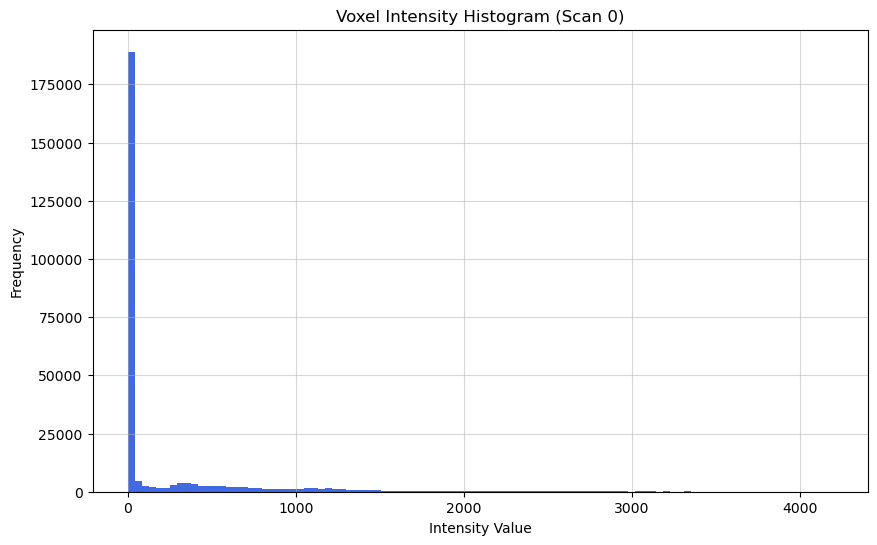

In [ ]:
# Calculate histogram using Dask. This is still lazy.
# We select the first scan for this example
print("Calculating histogram for the first scan...")
first_scan_array = dask_array[0, :, :]

# Define histogram bins
bins = np.linspace(first_scan_array.min().compute(), first_scan_array.max().compute(), 101)

# Compute the histogram. This is where the actual computation happens.
counts, edges = da.histogram(first_scan_array, bins=bins)
hist_counts, hist_edges = counts.compute(), edges # .compute() to get results
# Plot the results
plt.figure(figsize=(10, 6))
plt.bar(hist_edges[:-1], hist_counts, width=np.diff(hist_edges), align='edge', color='royalblue')
plt.title('Voxel Intensity Histogram (Scan 0)')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.5)
plt.show()

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import zarr
import tqdm  # Für eine schöne Fortschrittsanzeige

# =================================================================================
# 1. MODELL-DEFINITIONEN (müssen mit dem Training identisch sein)
# =================================================================================
# Kopiere die Klassen 'SpatialTransformer3D', 'UNet3D' und 'RegistrationModel'
# aus deinen vorherigen Skripten hierher.
class SpatialTransformer3D(nn.Module):
    def __init__(self, size):
        super().__init__()
        vectors = [torch.arange(0, s) for s in size]
        grids = torch.meshgrid(vectors, indexing='ij')
        grid = torch.stack(grids)
        grid = grid.unsqueeze(0)
        self.register_buffer('grid', grid.float(), persistent=False)
    def forward(self, src, flow):
        new_locs = self.grid + flow
        shape = flow.shape[2:]
        for i in range(len(shape)):
            new_locs[:, i, ...] = 2 * (new_locs[:, i, ...] / (shape[i] - 1) - 0.5)
        new_locs = new_locs.permute(0, 2, 3, 4, 1)
        new_locs = new_locs[..., [2, 1, 0]]
        return F.grid_sample(src, new_locs, align_corners=True, padding_mode="border")

class UNet3D(nn.Module):
    def __init__(self, in_channels=2, out_channels=3):
        super().__init__()
        self.enc1 = self._conv_block(in_channels, 16)
        self.enc2 = self._conv_block(16, 32)
        self.pool = nn.MaxPool3d(2)
        self.bottleneck = self._conv_block(32, 64)
        self.upconv2 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec2 = self._conv_block(64, 32)
        self.upconv1 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.dec1 = self._conv_block(32, 16)
        self.final_conv = nn.Conv3d(16, out_channels, kernel_size=1)
        self.final_conv.weight.data.zero_()
        self.final_conv.bias.data.zero_()
    def _conv_block(self, in_c, out_c):
        return nn.Sequential(nn.Conv3d(in_c, out_c, 3, 1, 1), nn.ReLU(True), nn.Conv3d(out_c, out_c, 3, 1, 1), nn.ReLU(True))
    def forward(self, x_fixed, x_moving):
        x = torch.cat([x_fixed, x_moving], dim=1)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.upconv2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.final_conv(d1)

class RegistrationModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.registration_net = UNet3D()
        self.spatial_transformer = SpatialTransformer3D(size=input_size)
    def forward(self, moving, fixed):
        displacement_field = self.registration_net(fixed, moving)
        warped_moving = self.spatial_transformer(moving, displacement_field)
        return warped_moving, displacement_field

# =================================================================================
# 2. BATCH-VERARBEITUNGS-SKRIPT
# =================================================================================
if __name__ == '__main__':
    # --- Konfiguration ---
    MODEL_PATH = "../DCE_codeset/registration_model_Bat1_50Ep_1e-3_NewLoss_SmoothWeight1e-3.pth"
    # KORREKTUR: Ein Pfad für die Input-Daten ist notwendig
    #INPUT_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/mdreg_DCE_fitting_results/coreg_zarr_2.zarr"
    OUTPUT_ZARR_PATH = "MEDCIC_07_codeset/MRI-Datasets/Outputs/warped_test/warped_results_model_test1.zarr"
    OUTPUT_DVF_PATH = "MEDCIC_07_codeset/MRI-Datasets/Outputs/warped_test/dvf_results_model_test1.zarr"

    # --- Setup ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Verwende Gerät: {device}")

    if os.path.exists(OUTPUT_ZARR_PATH) or os.path.exists(OUTPUT_DVF_PATH):
        raise FileExistsError("Eine der Ausgabedateien existiert bereits. Bitte löschen oder umbenennen.")

    dask_array = dask_array

    # --- Modell laden ---
    print(f"Lade trainiertes Modell von: {MODEL_PATH}")
    # KORREKTUR: .compute() hier entfernt. Shape wird direkt vom Dask-Objekt genommen.
    original_shape = dask_array.shape 
    padded_shape = list(original_shape[:3]) # Nimm H, W, D
    
    for i in range(3):
        if padded_shape[i] % 4 != 0:
            padded_shape[i] = (padded_shape[i] // 4 + 1) * 4
    input_size = (padded_shape[2], padded_shape[0], padded_shape[1])

    model = RegistrationModel(input_size=input_size).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("Modell erfolgreich geladen.")

    # --- Daten-Setup ---
    # KORREKTUR: Die .compute() Aufrufe hier werden entfernt. 
    # Wir arbeiten direkt mit dem 'dask_array'-Objekt.
    
    # Erstelle die leere Zarr-Datei für die Ausgabe
    print(f"Erstelle Ausgabedatei: {OUTPUT_ZARR_PATH}")
    output_zarr = zarr.open(OUTPUT_ZARR_PATH, mode='w', 
                            shape=dask_array.shape, 
                            # KORREKTUR: .chunksize für Dask-Arrays, .chunks für Zarr-Arrays
                            chunks=dask_array.chunksize, 
                            dtype=dask_array.dtype)
    
    dvf_shape = list(dask_array.shape) + [3]
    dvf_chunks = list(dask_array.chunksize) + [3]
    dvf_output_zarr = zarr.open(OUTPUT_DVF_PATH, mode='w',
                                shape=tuple(dvf_shape),
                                chunks=tuple(dvf_chunks),
                                dtype='float32')

    # --- Lade das fixe Referenzbild vor ---
    print("Lade und verarbeite fixes Referenzbild...")
    # KORREKTUR: .compute() wird hier nur für das EINE Referenzbild aufgerufen
    fixed_np = dask_array[..., 0].compute() 
    
    def preprocess_volume(volume_np, padded_shape):
        tensor = torch.from_numpy(volume_np.astype(np.float32)).permute(2, 0, 1)
        tensor = tensor.unsqueeze(0)
        pad_d = padded_shape[2] - tensor.shape[1]
        pad_h = padded_shape[0] - tensor.shape[2]
        pad_w = padded_shape[1] - tensor.shape[3]
        padding = (pad_w // 2, pad_w - pad_w // 2, pad_h // 2, pad_h - pad_h // 2, pad_d // 2, pad_d - pad_d // 2)
        return F.pad(tensor, padding, "constant", 0)

    fixed_tensor = preprocess_volume(fixed_np, padded_shape).to(device)
    fixed_tensor_batch = fixed_tensor.unsqueeze(0)

    # --- Hauptverarbeitungsschleife ---
    num_images = dask_array.shape[3]
    print(f"Starte Verarbeitung von {num_images} Volumen...")

    with torch.no_grad():
        for i in tqdm.trange(num_images, desc="Verarbeite Volumen"):
            # 1. Lese ein "moving" Volumen und lade es mit .compute() in den Speicher
            # KORREKTUR: Lade nur das aktuell benötigte Volumen!
            moving_np = dask_array[..., i].compute()
            
            # 2. Wende die gleiche Vorverarbeitung an
            moving_tensor = preprocess_volume(moving_np, padded_shape).to(device)
            moving_tensor_batch = moving_tensor.unsqueeze(0)

            # 3. Führe die Inferenz durch
            warped_batch, displacement_batch = model(moving_tensor_batch, fixed_tensor_batch)

            # 4. Nachbearbeitung
            warped_tensor = warped_batch.squeeze(0)
            disp_field = displacement_batch.squeeze(0)
            
            pad_d_start = (padded_shape[2] - original_shape[2]) // 2
            pad_h_start = (padded_shape[0] - original_shape[0]) // 2
            pad_w_start = (padded_shape[1] - original_shape[1]) // 2
            
            cropped_warped = warped_tensor[:, pad_d_start:pad_d_start + original_shape[2], pad_h_start:pad_h_start + original_shape[0], pad_w_start:pad_w_start + original_shape[1]]
            cropped_disp = disp_field[:, pad_d_start:pad_d_start + original_shape[2], pad_h_start:pad_h_start + original_shape[0], pad_w_start:pad_w_start + original_shape[1]]
            
            warped_np = cropped_warped.squeeze(0).cpu().numpy().transpose(1, 2, 0)
            dvf_np = cropped_disp.permute(2, 3, 1, 0).cpu().numpy()

            # 5. Speichere das Ergebnis
            output_zarr[..., i] = warped_np
            dvf_output_zarr[..., i, :] = dvf_np
            
    print(f"\n✔️ Verarbeitung abgeschlossen.")
    print(f"Ergebnisse gespeichert in: {OUTPUT_ZARR_PATH}")
    print(f"DVF gespeichert in: {OUTPUT_DVF_PATH}")

Verwende Gerät: cuda
Lade trainiertes Modell von: ../DCE_codeset/registration_model_Bat1_50Ep_1e-3_NewLoss_SmoothWeight1e-3.pth
Modell erfolgreich geladen.
Erstelle Ausgabedatei: MEDCIC_07_codeset/MRI-Datasets/Outputs/warped_test/warped_results_model_test1.zarr
Lade und verarbeite fixes Referenzbild...
Starte Verarbeitung von 250 Volumen...


Verarbeite Volumen: 100%|██████████| 250/250 [02:54<00:00,  1.43it/s]


✔️ Verarbeitung abgeschlossen.
Ergebnisse gespeichert in: MEDCIC_07_codeset/MRI-Datasets/Outputs/warped_test/warped_results_model_test1.zarr
DVF gespeichert in: MEDCIC_07_codeset/MRI-Datasets/Outputs/warped_test/dvf_results_model_test1.zarr


In [ ]:
out = da.from_array(output_zarr)
out

dask.array<array, shape=(256, 256, 50, 250), dtype=int16, chunksize=(256, 256, 50, 20), chunktype=numpy.ndarray>

In [ ]:
dask_array

dask.array<transpose, shape=(256, 256, 50, 250), dtype=int16, chunksize=(128, 128, 50, 1), chunktype=numpy.ndarray>

In [ ]:
slide_array = out[:,:,14,:]
slide_array = np.transpose(slide_array, [2,1,0])

In [ ]:
slide_array_2 = dask_array[:,:,14,:]
slide_array_2 = np.transpose(slide_array_2, [2,1,0])

In [26]:
coreg

array([[[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        ...,

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
    

In [31]:
co = coreg[:,:,:,41]
co = np.transpose(co, [2,1,0])


In [32]:
helpers.explore_3D_array(co)

interactive(children=(IntSlider(value=24, description='SLICE', max=49), Output()), _dom_classes=('widget-inter…

In [ ]:
helpers.explore_3D_array_comparison_and_diff(slide_array_2,slide_array)

interactive(children=(IntSlider(value=125, description='Slice:', max=249), Output()), _dom_classes=('widget-in…

In [ ]:
slide_array = out[:,:,15,:]
slide_array = np.transpose(slide_array, [2,1,0])
slide_array_2 = dask_array[:,:,15,:]
slide_array_2 = np.transpose(slide_array_2, [2,1,0])

In [ ]:
helpers.explore_3D_array_comparison_and_diff(slide_array_2,slide_array)

interactive(children=(IntSlider(value=125, description='Slice:', max=249), Output()), _dom_classes=('widget-in…

In [ ]:
slide_array = out[:,:,16,:]
slide_array = np.transpose(slide_array, [2,1,0])
slide_array_2 = dask_array[:,:,16,:]
slide_array_2 = np.transpose(slide_array_2, [2,1,0])

In [ ]:
helpers.explore_3D_array_comparison_and_diff(slide_array_2,slide_array)

interactive(children=(IntSlider(value=125, description='Slice:', max=249), Output()), _dom_classes=('widget-in…

In [ ]:
slide_array = out[:,:,17,:]
slide_array = np.transpose(slide_array, [2,1,0])
slide_array_2 = dask_array[:,:,17,:]
slide_array_2 = np.transpose(slide_array_2, [2,1,0])

In [ ]:
helpers.explore_3D_array_comparison_and_diff(slide_array_2,slide_array)

interactive(children=(IntSlider(value=125, description='Slice:', max=249), Output()), _dom_classes=('widget-in…

In [ ]:
slide_array = out[:,:,18,:]
slide_array = np.transpose(slide_array, [2,1,0])
slide_array_2 = dask_array[:,:,18,:]
slide_array_2 = np.transpose(slide_array_2, [2,1,0])

In [ ]:
helpers.explore_3D_array_comparison_and_diff(slide_array_2,slide_array)

interactive(children=(IntSlider(value=125, description='Slice:', max=249), Output()), _dom_classes=('widget-in…